
Description of the Assignment

As we discussed before the linear regression model, and how we update the model's parameters with the gradient vector and the learning rate

You are supposed to implement the model using numpy package in three flavours:
stocastic gradient descent
Mini batch gradient descent
Batch gradient descent
Where you have the following equations:


MSE: J(w)=12m∑mi=1(w⊤x(i)−y(i))2

Hypothesis fn: y^(i)=w⊤x(i)

Gradient Vector: ∂J(w)∂wj=1m∑mi=1(w⊤x(i)−y(i))x(i)j

Weight Update: w(k+1)=w(k)−α∇wJ(w)





In [ ]:
# Importing numpy
import numpy as np

In [ ]:
# Initializing random numbers
np.random.seed(42)

In [ ]:
# Number of Samples
m=1000

In [ ]:
# features --independent variables initialization
X=3*np.random.rand(m,3)
X.shape

(1000, 3)

In [ ]:
X

array([[1.12362036, 2.85214292, 2.19598183],
       [1.79597545, 0.46805592, 0.46798356],
       [0.17425084, 2.59852844, 1.80334504],
       ...,
       [2.40001045, 1.65812123, 1.18966105],
       [0.39514509, 2.59588728, 0.47181962],
       [0.92936358, 0.8701366 , 2.6142421 ]])

In [ ]:
# labels -- dependent variables initialization
y=6+(2*X[:,0])+(3*X[:,1])+(4*X[:,2])+ np.random.randn(m,1).flatten()

In [ ]:
y.shape

(1000,)

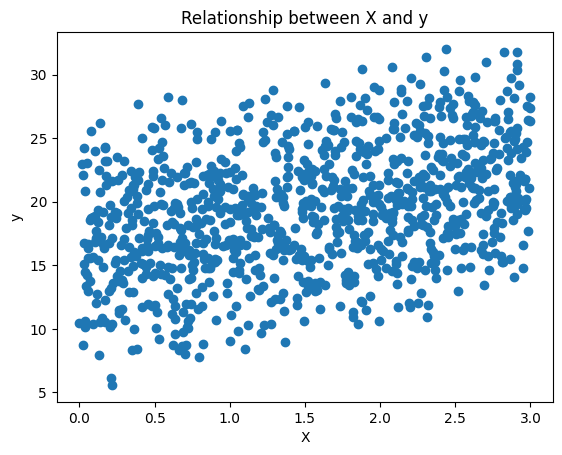

In [ ]:
# Showing Relationship between x and y
import matplotlib.pyplot as plt
plt.scatter(X[:,0],y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Relationship between X and y')
plt.show()

In [ ]:
from sklearn.preprocessing import add_dummy_feature

In [ ]:
X_b=add_dummy_feature(X)

In [ ]:
X_b.shape

(1000, 4)

In [ ]:
X_b[0]

array([1.        , 1.12362036, 2.85214292, 2.19598183])

In [ ]:
X_b

array([[1.        , 1.12362036, 2.85214292, 2.19598183],
       [1.        , 1.79597545, 0.46805592, 0.46798356],
       [1.        , 0.17425084, 2.59852844, 1.80334504],
       ...,
       [1.        , 2.40001045, 1.65812123, 1.18966105],
       [1.        , 0.39514509, 2.59588728, 0.47181962],
       [1.        , 0.92936358, 0.8701366 , 2.6142421 ]])

In [ ]:
X_b.shape

(1000, 4)

In [ ]:
y.shape

(1000,)

In [ ]:
theta_best=np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [ ]:
X_b.T.shape

(4, 1000)

In [ ]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
X.shape

(1000, 3)

In [ ]:
y.shape

(1000,)

In [ ]:
LR.fit(X,y)

LinearRegression()

In [ ]:
LR.coef_

array([2.02122218, 3.00262261, 3.9745656 ])

In [ ]:
LR.intercept_

np.float64(6.003456103098266)

In [ ]:
theta_best

array([6.0034561 , 2.02122218, 3.00262261, 3.9745656 ])

In [ ]:
# Stochastic Gradient Descent
from sklearn.linear_model import SGDRegressor

In [ ]:
SGD=SGDRegressor(max_iter=1000, penalty=None,eta0 = 0.01, n_iter_no_change=100,random_state=42)

In [ ]:
SGD.fit(X,y)

SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42)

In [ ]:
SGD.intercept_

array([6.00316713])

In [ ]:
SGD.coef_

array([2.02012772, 3.00489169, 3.9767615 ])

In [ ]:
mini_gd = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)


Another method

In [ ]:
import numpy as np

np.random.seed(42)

m = 100  # number of samples
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(m)

X = np.c_[np.ones((m, 1)), X]  # add bias term


In [ ]:

def compute_gradients(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    error = predictions - y
    gradients = (1/m) * X.T.dot(error)
    return gradients


In [ ]:
#  Batch Gradient Descent
def batch_gradient_descent(X, y, lr=0.1, epochs=1000):
    theta = np.zeros(X.shape[1])

    for _ in range(epochs):
        gradients = compute_gradients(X, y, theta)
        theta -= lr * gradients

    return theta


In [ ]:
# stochastic gradient descent
def stochastic_gradient_descent(X, y, lr=0.01, epochs=50):
    theta = np.zeros(X.shape[1])
    m = len(y)

    for _ in range(epochs):
        for i in range(m):
            xi = X[i:i+1]
            yi = y[i:i+1]
            gradients = compute_gradients(xi, yi, theta)
            theta -= lr * gradients

    return theta


In [ ]:
# Mini Batch gradient descent
def mini_batch_gradient_descent(X, y, lr=0.05, epochs=200, batch_size=20):
    theta = np.zeros(X.shape[1])
    m = len(y)

    for _ in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            gradients = compute_gradients(xi, yi, theta)
            theta -= lr * gradients

    return theta


In [ ]:
theta_batch = batch_gradient_descent(X, y)
theta_sgd = stochastic_gradient_descent(X, y)
theta_mini = mini_batch_gradient_descent(X, y)

print("Batch GD theta:", theta_batch)
print("SGD theta:", theta_sgd)
print("Mini-Batch GD theta:", theta_mini)


Batch GD theta: [4.21509612 2.77011342]
SGD theta: [4.24050136 2.8172062 ]
Mini-Batch GD theta: [4.21202363 2.76634124]


The End of The Assignment